# Predicting High-Performing Firms Using Financial Ratios and Machine Learning

**Project objective:** classify companies as high-performing or low-performing using engineered financial ratios and machine learning models.

This notebook is organised for portfolio presentation. It follows the full workflow from data loading, feature engineering and EDA to hypothesis testing, modelling, interpretation and business cost analysis.

**Final selected model:** Logistic Regression with PCA, selected because it achieved the highest recall while maintaining interpretability.

## 1. Import Libraries

This section imports the Python libraries used for data preparation, visualisation, statistical testing and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, chi2_contingency

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

pd.set_option('display.max_columns', None)

## 2. Load Dataset

The dataset contains firm-level financial variables. A copy of the original data is kept for later interpretation, especially for ROA distribution and cost analysis.



In [2]:
DATA_PATH = 'final_dataset.csv'

df = pd.read_csv(DATA_PATH)
dforiginal = df.copy()

df.head()

,company_id,name_latest,Assets,CashAndCashEquivalentsAtCarryingValue,CashAndCashEquivalentsPeriodIncreaseDecrease,LiabilitiesAndStockholdersEquity,NetIncomeLoss,PropertyPlantAndEquipmentNet,RetainedEarningsAccumulatedDeficit,StockholdersEquity
0,1750,AAR Corp,1.865480e+09,6.259217e+07,-11687400.0,1.865480e+09,5.389150e+07,3.052517e+08,5.974503e+08,8.927388e+08
1,1800,Abbott Laboratories,5.059737e+10,6.030797e+09,-659137750.0,5.059737e+10,3.094333e+09,6.701400e+09,2.313367e+10,2.381376e+10
2,1961,Worlds Inc,2.823840e+05,5.860050e+04,NaN,2.823840e+05,-2.703092e+06,1.089100e+04,-3.354940e+07,-4.258971e+06
3,2034,Aceto Corp,4.242492e+08,4.036760e+07,7632800.0,4.242492e+08,2.731160e+07,1.103760e+07,1.447478e+08,2.309760e+08
4,2098,Acme United Corp,7.037160e+07,6.791704e+06,-835105.0,7.037160e+07,3.989172e+06,5.025528e+06,3.054185e+07,3.525162e+07


In [3]:
print('Rows and columns:', df.shape)
df.info()

Rows and columns: (9586, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9586 entries, 0 to 9585
Data columns (total 10 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   company_id                                    9586 non-null   int64  
 1   name_latest                                   9586 non-null   object 
 2   Assets                                        9460 non-null   float64
 3   CashAndCashEquivalentsAtCarryingValue         8735 non-null   float64
 4   CashAndCashEquivalentsPeriodIncreaseDecrease  8412 non-null   float64
 5   LiabilitiesAndStockholdersEquity              9469 non-null   float64
 6   NetIncomeLoss                                 8926 non-null   float64
 7   PropertyPlantAndEquipmentNet                  7430 non-null   float64
 8   RetainedEarningsAccumulatedDeficit            8374 non-null   float64
 9   StockholdersEquity                

## 3. Feature Engineering

Raw accounting values can be difficult to compare across firms of different sizes. For this reason, financial ratios were created to standardise the variables and improve interpretability.

Created features:
- `ROA`: Net Income / Assets
- `leverage`: Liabilities / Assets
- `cash_ratio`: Cash / Assets
- `ppe_ratio`: PPE / Assets
- `retained_ratio`: Retained Earnings / Assets
- `size`: Small / Medium / Large based on asset quantiles
- `high_performance`: binary target based on whether ROA is above the median

In [4]:
# Create liabilities if not already available
df['Liabilities'] = df['Assets'] - df['StockholdersEquity']

# Profitability target variable
df['ROA'] = df['NetIncomeLoss'] / df['Assets'].replace(0, np.nan)

# Engineered financial ratios
df['leverage'] = df['Liabilities'] / df['Assets'].replace(0, np.nan)
df['cash_ratio'] = df['CashAndCashEquivalentsAtCarryingValue'] / df['Assets'].replace(0, np.nan)
df['ppe_ratio'] = df['PropertyPlantAndEquipmentNet'] / df['Assets'].replace(0, np.nan)
df['equity_ratio'] = df['StockholdersEquity'] / df['Assets'].replace(0, np.nan)
df['retained_ratio'] = df['RetainedEarningsAccumulatedDeficit'] / df['Assets'].replace(0, np.nan)

# Company size category based on assets
df['size'] = pd.qcut(
    df['Assets'],
    q=3,
    labels=['Small', 'Medium', 'Large'],
    duplicates='drop'
)

# Optional risk category based on leverage, retained for analysis but not final modelling
try:
    df['risk'] = pd.qcut(
        df['leverage'],
        q=3,
        labels=['Low', 'Medium', 'High'],
        duplicates='drop'
    )
except ValueError:
    pass

# Binary target: 1 if ROA is above median, otherwise 0
df['high_performance'] = (df['ROA'] > df['ROA'].median()).astype(int)

# Replace infinities created by divisions with NaN
replace_cols = ['ROA', 'leverage', 'cash_ratio', 'ppe_ratio', 'equity_ratio', 'retained_ratio']
df[replace_cols] = df[replace_cols].replace([np.inf, -np.inf], np.nan)

# Update original analytical copy after feature engineering
dforiginal = df.copy()

df[['ROA', 'leverage', 'cash_ratio', 'ppe_ratio', 'retained_ratio', 'size', 'high_performance']].head()

,ROA,leverage,cash_ratio,ppe_ratio,retained_ratio,size,high_performance
0,0.028889,0.521443,0.033553,0.163632,0.320266,Large,1
1,0.061156,0.529348,0.119192,0.132446,0.457211,Large,1
2,-9.572399,16.082197,0.207521,0.038568,-118.807725,Small,0
3,0.064376,0.455565,0.095151,0.026017,0.341186,Medium,1
4,0.056687,0.499065,0.096512,0.071414,0.434008,Medium,1


## 4. Exploratory Data Analysis (EDA)

EDA was performed after feature engineering because ratios are more meaningful than raw accounting values when comparing firms of different sizes.

In [5]:
# Missing values as percentages
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
missing_percent.head(15)

ppe_ratio                                       22.616315
PropertyPlantAndEquipmentNet                    22.491133
retained_ratio                                  13.999583
RetainedEarningsAccumulatedDeficit              12.643438
CashAndCashEquivalentsPeriodIncreaseDecrease    12.247027
cash_ratio                                      10.014605
leverage                                         9.513874
equity_ratio                                     9.513874
risk                                             9.513874
CashAndCashEquivalentsAtCarryingValue            8.877530
Liabilities                                      8.773211
ROA                                              8.762779
StockholdersEquity                               7.750887
NetIncomeLoss                                    6.885041
Assets                                           1.314417
dtype: float64

In [6]:
# Target balance
(df['high_performance'].value_counts(normalize=True) * 100).round(2)

high_performance
0    54.38
1    45.62
Name: proportion, dtype: float64

### 4.1 Correlation Heatmap

The heatmap was used to understand relationships between numerical variables and identify potential multicollinearity before feature selection.

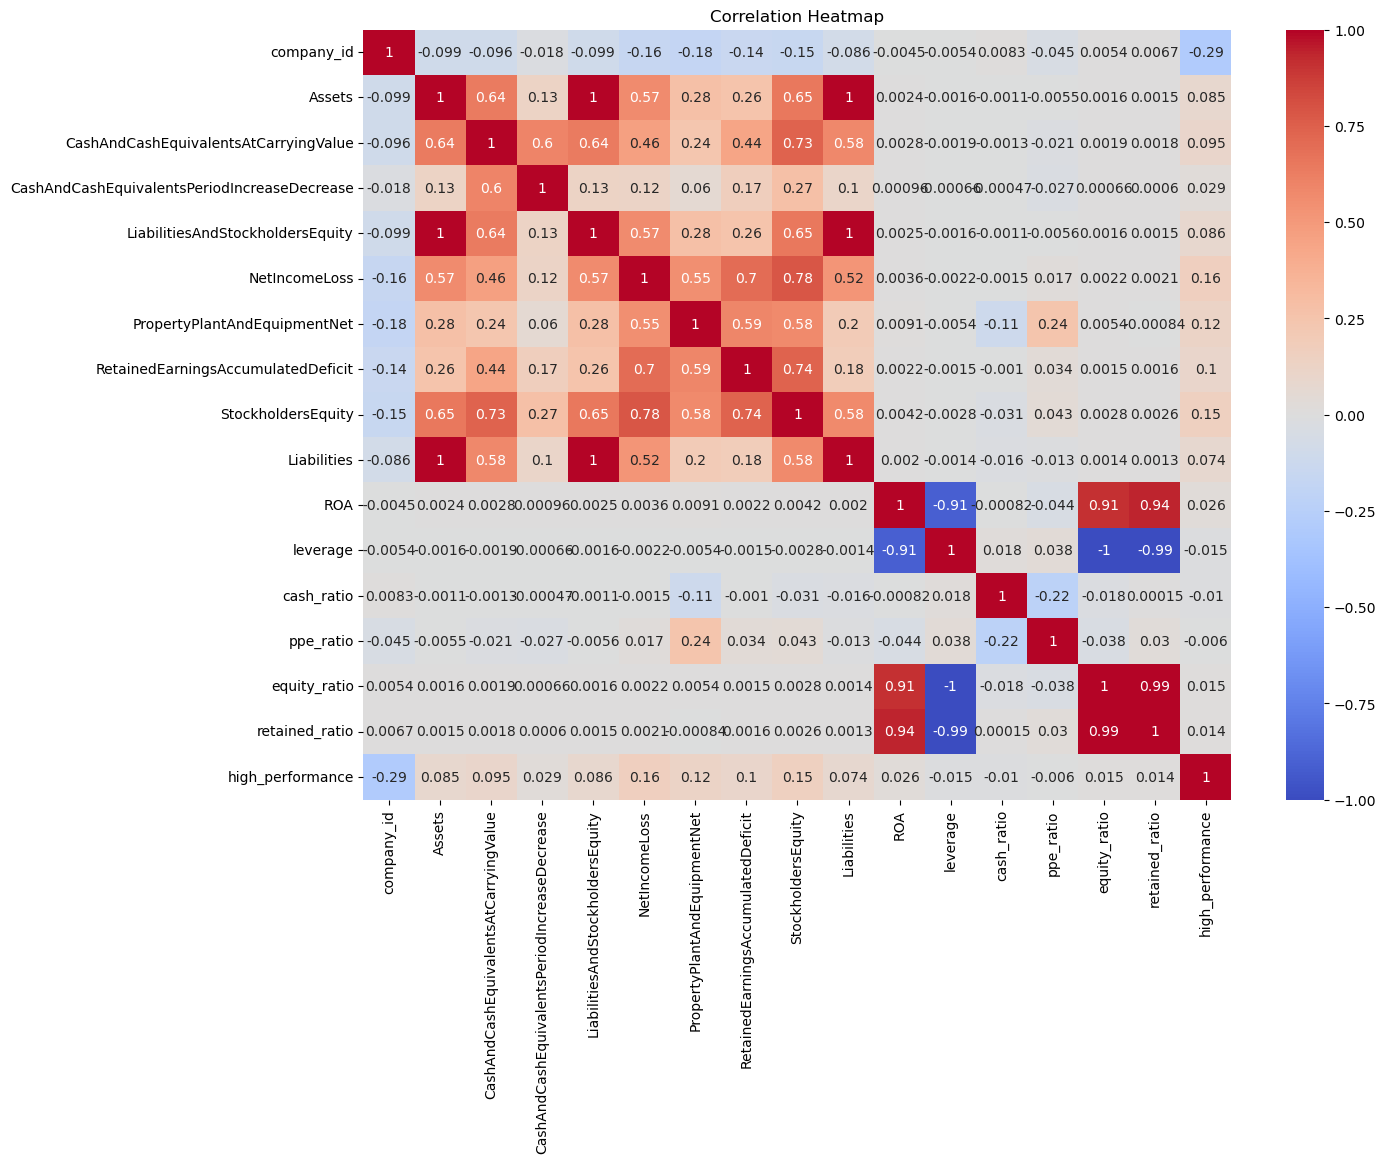

In [7]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.2 ROA Distribution

ROA contained extreme outliers and was highly skewed. For visualisation, the middle 98% of ROA values was plotted to make the main distribution readable. This does not change the original dataset; it is only for visual clarity.

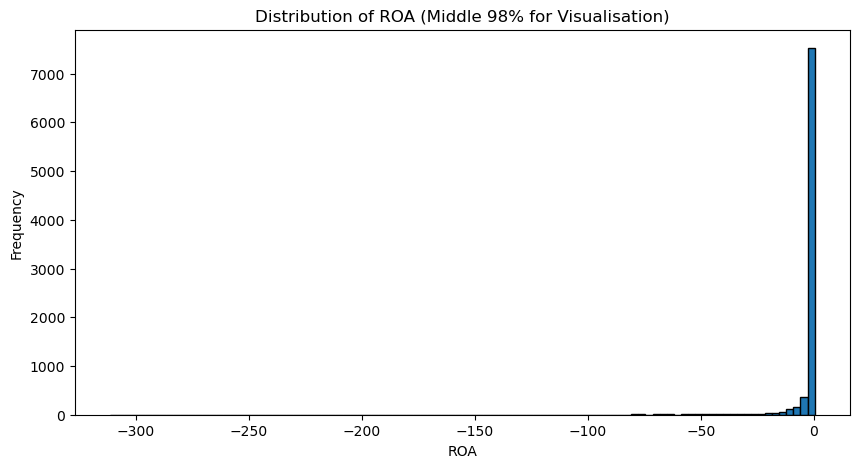

In [8]:
roa_clean = df['ROA'].replace([np.inf, -np.inf], np.nan).dropna()

roa_plot = roa_clean[
    (roa_clean >= roa_clean.quantile(0.01)) &
    (roa_clean <= roa_clean.quantile(0.99))
]

plt.figure(figsize=(10, 5))
plt.hist(roa_plot, bins=100, edgecolor='black')
plt.xlabel('ROA')
plt.ylabel('Frequency')
plt.title('Distribution of ROA (Middle 98% for Visualisation)')
plt.savefig('roa_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Hypothesis Testing

Because financial data was skewed and contained outliers, non-parametric tests were used. Mann–Whitney U tests compared continuous variables between high-performing and low-performing firms. A Chi-square test was used for the categorical `size` variable.

In [9]:
def mann_whitney_test(feature):
    group0 = df[df['high_performance'] == 0][feature].dropna()
    group1 = df[df['high_performance'] == 1][feature].dropna()
    stat, p_value = mannwhitneyu(group0, group1)
    return p_value

hypothesis_results = pd.DataFrame({
    'Variable': ['leverage', 'cash_ratio', 'ppe_ratio'],
    'Test': ['Mann–Whitney U', 'Mann–Whitney U', 'Mann–Whitney U'],
    'P-value': [
        mann_whitney_test('leverage'),
        mann_whitney_test('cash_ratio'),
        mann_whitney_test('ppe_ratio')
    ]
})

# Chi-square test for size
contingency = pd.crosstab(df['size'], df['high_performance'])
chi2, p_size, dof, expected = chi2_contingency(contingency)

hypothesis_results = pd.concat([
    hypothesis_results,
    pd.DataFrame({'Variable': ['size'], 'Test': ['Chi-square'], 'P-value': [p_size]})
], ignore_index=True)

hypothesis_results

,Variable,Test,P-value
0,leverage,Mann–Whitney U,7.246590e-88
1,cash_ratio,Mann–Whitney U,3.233730e-130
2,ppe_ratio,Mann–Whitney U,2.566302e-03
3,size,Chi-square,0.000000e+00


**Interpretation:** All tested variables showed statistically significant differences or associations with performance groups. This supported the inclusion of these features in the modelling stage.

## 6. Feature Selection

Feature selection was based on:
- correlation analysis,
- financial domain knowledge,
- interpretability,
- and leakage prevention.

Variables used to compute the target, such as `ROA`, `NetIncomeLoss`, and raw `Assets`, were excluded from the model features to avoid data leakage. The final interpretable feature set includes financial ratios and company size.

In [10]:
features = ['leverage', 'cash_ratio', 'ppe_ratio', 'size']
target = 'high_performance'

# Drop rows where target is missing, then create X and y
df_model = df.dropna(subset=[target]).copy()

X = df_model[features].copy()
y = df_model[target]

X.head()

,leverage,cash_ratio,ppe_ratio,size
0,0.521443,0.033553,0.163632,Large
1,0.529348,0.119192,0.132446,Large
2,16.082197,0.207521,0.038568,Small
3,0.455565,0.095151,0.026017,Medium
4,0.499065,0.096512,0.071414,Medium


## 7. Train/Test Split and Preprocessing

The dataset was split before imputation and transformation to avoid data leakage.

Preprocessing was handled with a `ColumnTransformer`:
- numerical variables were imputed using the **training median** and then standardised;
- categorical variables were imputed using the most frequent category and then one-hot encoded.

This prevents errors such as `LogisticRegression does not accept missing values encoded as NaN`.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

categorical_cols = ['size']
numerical_cols = ['leverage', 'cash_ratio', 'ppe_ratio']

# Important: do not manually fill missing values before the split.
# The imputer below learns from the training data only, then applies the same rules to the test data.

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer: categorical first, numerical second
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols),
        ('num', numeric_transformer, numerical_cols)
    ]
)

X_traintrans = preprocessor.fit_transform(X_train)
X_testtrans = preprocessor.transform(X_test)

# Recover transformed feature names for interpretation
cat_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
feature_names = list(cat_names) + numerical_cols

print('Transformed train shape:', X_traintrans.shape)
print('Transformed test shape:', X_testtrans.shape)
print('Feature names:', feature_names)
print('Missing values after preprocessing - train:', np.isnan(X_traintrans).sum())
print('Missing values after preprocessing - test:', np.isnan(X_testtrans).sum())


Transformed train shape: (7668, 6)
Transformed test shape: (1918, 6)
Feature names: ['size_Large', 'size_Medium', 'size_Small', 'leverage', 'cash_ratio', 'ppe_ratio']
Missing values after preprocessing - train: 0
Missing values after preprocessing - test: 0


## 8. Model Evaluation Helper Function

This function evaluates each model using accuracy, precision and recall. Recall was prioritised because missing high-performing firms represents a lost opportunity.

In [12]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0)
    }

## 9. Baseline Model

A dummy classifier was used as a baseline. It predicts the most frequent class and helps confirm whether machine learning models add value beyond a simple rule.

In [13]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_traintrans, y_train)
y_pred_dummy = dummy.predict(X_testtrans)

evaluate_model('Dummy Baseline', y_test, y_pred_dummy)

{'Model': 'Dummy Baseline',
 'Accuracy': 0.5437956204379562,
 'Precision': 0.0,
 'Recall': 0.0}

## 10. Logistic Regression

Logistic Regression was used because it is interpretable and provides coefficients showing the direction of feature impact.

In [14]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_traintrans, y_train)
y_pred_lr = log_model.predict(X_testtrans)

evaluate_model('Logistic Regression', y_test, y_pred_lr)

{'Model': 'Logistic Regression',
 'Accuracy': 0.7413972888425443,
 'Precision': 0.8003169572107766,
 'Recall': 0.5771428571428572}

### Logistic Regression with PCA

PCA was tested to reduce noise and improve model performance. The model with PCA achieved the best recall and was selected as the final model.

In [15]:
# Compare PCA components
pca_results = []

for n in [2, 3, 4]:
    pca_temp = PCA(n_components=n)
    X_train_pca_temp = pca_temp.fit_transform(X_traintrans)
    X_test_pca_temp = pca_temp.transform(X_testtrans)

    model_temp = LogisticRegression(max_iter=1000)
    model_temp.fit(X_train_pca_temp, y_train)
    y_pred_temp = model_temp.predict(X_test_pca_temp)

    result = evaluate_model(f'Logistic + PCA ({n} components)', y_test, y_pred_temp)
    result['Components'] = n
    pca_results.append(result)

pd.DataFrame(pca_results)

,Model,Accuracy,Precision,Recall,Components
0,Logistic + PCA (2 components),0.548488,0.525140,0.107429,2
1,Logistic + PCA (3 components),0.602190,0.600000,0.384000,3
2,Logistic + PCA (4 components),0.572993,0.533493,0.509714,4


In [16]:
# Final PCA model
PCA_COMPONENTS = 3

pca = PCA(n_components=PCA_COMPONENTS)
X_train_pca = pca.fit_transform(X_traintrans)
X_test_pca = pca.transform(X_testtrans)

model_lr_pca = LogisticRegression(max_iter=1000)
model_lr_pca.fit(X_train_pca, y_train)

y_pred_lr_pca = model_lr_pca.predict(X_test_pca)

evaluate_model('Logistic Regression + PCA', y_test, y_pred_lr_pca)

{'Model': 'Logistic Regression + PCA',
 'Accuracy': 0.6021897810218978,
 'Precision': 0.6,
 'Recall': 0.384}

## 11. Support Vector Machine (SVM)

SVM was tested because it can capture more complex decision boundaries. It performed strongly on recall, but Logistic Regression with PCA was preferred due to its balance of recall and interpretability.

In [17]:
model_svm = SVC(class_weight='balanced', probability=True, random_state=42)
model_svm.fit(X_traintrans, y_train)
y_pred_svm = model_svm.predict(X_testtrans)

evaluate_model('SVM', y_test, y_pred_svm)

{'Model': 'SVM',
 'Accuracy': 0.7533889468196038,
 'Precision': 0.7321016166281755,
 'Recall': 0.7245714285714285}

## 12. Random Forest

Random Forest was used as a non-linear tree-based model. It achieved strong accuracy and precision, and was also useful for feature importance analysis.

In [18]:
# Random Forest can use an extended feature set. Scaling is not required, but categorical variables must be encoded.
features_rf = ['leverage', 'cash_ratio', 'ppe_ratio', 'retained_ratio', 'size']
X_rf = df_model[features_rf].copy()
y_rf = df_model[target]

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.20,
    random_state=42,
    stratify=y_rf
)

# Fill numerical values using training medians
num_cols_rf = X_train_rf.select_dtypes(include='number').columns
median_rf = X_train_rf[num_cols_rf].median()
X_train_rf[num_cols_rf] = X_train_rf[num_cols_rf].fillna(median_rf)
X_test_rf[num_cols_rf] = X_test_rf[num_cols_rf].fillna(median_rf)

# Handle categorical values
X_train_rf['size'] = X_train_rf['size'].astype(str).replace('nan', 'Unknown')
X_test_rf['size'] = X_test_rf['size'].astype(str).replace('nan', 'Unknown')

# One-hot encode and align train/test columns
X_train_rf = pd.get_dummies(X_train_rf, columns=['size'], drop_first=False)
X_test_rf = pd.get_dummies(X_test_rf, columns=['size'], drop_first=False)
X_train_rf, X_test_rf = X_train_rf.align(X_test_rf, join='left', axis=1, fill_value=0)

model_rf = RandomForestClassifier(random_state=42, n_estimators=200)
model_rf.fit(X_train_rf, y_train_rf)

y_pred_rf = model_rf.predict(X_test_rf)

evaluate_model('Random Forest', y_test_rf, y_pred_rf)

{'Model': 'Random Forest',
 'Accuracy': 0.8279457768508863,
 'Precision': 0.802441731409545,
 'Recall': 0.8262857142857143}

## 13. Model Comparison

The final model comparison shows the trade-off between accuracy, precision and recall. Logistic Regression with PCA was selected because it achieved the highest recall, which aligned with the business goal of identifying as many high-performing firms as possible.

In [19]:
results = pd.DataFrame([
    evaluate_model('Logistic Regression + PCA', y_test, y_pred_lr_pca),
    evaluate_model('Random Forest', y_test_rf, y_pred_rf),
    evaluate_model('SVM', y_test, y_pred_svm)
])

results

,Model,Accuracy,Precision,Recall
0,Logistic Regression + PCA,0.602190,0.600000,0.384000
1,Random Forest,0.827946,0.802442,0.826286
2,SVM,0.753389,0.732102,0.724571


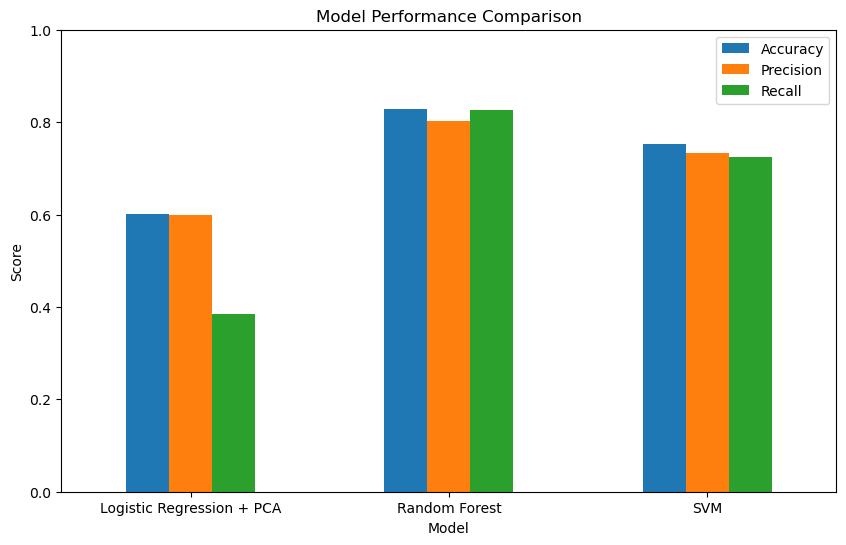

In [20]:
results.set_index('Model')[['Accuracy', 'Precision', 'Recall']].plot(kind='bar', figsize=(10, 6))
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Confusion Matrix for Final Model

The confusion matrix shows how many firms were correctly and incorrectly classified. The key business concern is reducing false negatives, because false negatives represent missed high-performing firms.

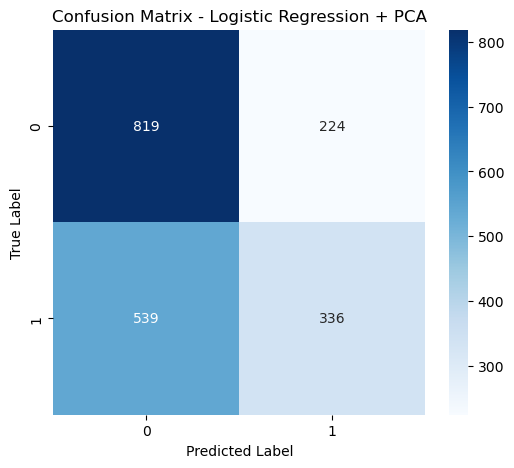

              precision    recall  f1-score   support

           0       0.60      0.79      0.68      1043
           1       0.60      0.38      0.47       875

    accuracy                           0.60      1918
   macro avg       0.60      0.58      0.58      1918
weighted avg       0.60      0.60      0.58      1918



In [21]:
cm = confusion_matrix(y_test, y_pred_lr_pca)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression + PCA')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_lr_pca))

## 15. ROC Curve

The ROC curve evaluates the classification model across different thresholds. The AUC score summarises how well the model separates the two classes.

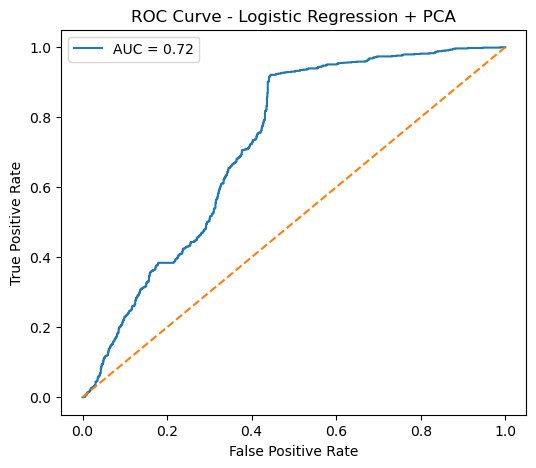

In [22]:
y_prob = model_lr_pca.predict_proba(X_test_pca)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression + PCA')
plt.legend()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 16. Feature Impact and Interpretation

Logistic Regression coefficients were used to understand the direction of feature impact. Positive coefficients increase the probability of high performance, while negative coefficients reduce it.

Because the final Logistic Regression model used PCA, the non-PCA Logistic Regression coefficients are used here for business interpretation.

In [23]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df

,Feature,Coefficient
0,size_Large,1.542704
1,size_Medium,0.146648
5,ppe_ratio,-0.026708
4,cash_ratio,-0.080503
3,leverage,-0.202529
2,size_Small,-1.903574


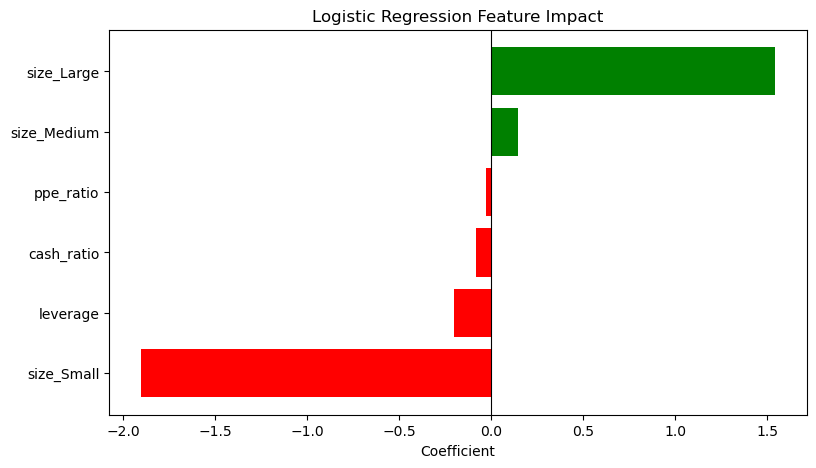

In [24]:
plt.figure(figsize=(9, 5))
colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient')
plt.title('Logistic Regression Feature Impact')
plt.gca().invert_yaxis()
plt.savefig('feature_impact.png', dpi=300, bbox_inches='tight')
plt.show()

## 17. Business Cost of Misclassification

Median ROA was used to estimate the financial cost of classification errors. Because ROA contained extreme outliers, median values were preferred over averages.

- False negative: missing a truly high-performing firm.
- False positive: selecting a low-performing firm.

This analysis supports prioritising recall.

In [25]:
# Remove extreme ROA outliers for cost interpretation
filtered_roa = dforiginal[
    (dforiginal['ROA'] > dforiginal['ROA'].quantile(0.01)) &
    (dforiginal['ROA'] < dforiginal['ROA'].quantile(0.99))
]

top_roa = filtered_roa[filtered_roa['high_performance'] == 1]['ROA'].median()
bottom_roa = filtered_roa[filtered_roa['high_performance'] == 0]['ROA'].median()
roa_gap = top_roa - bottom_roa

print('Median ROA - High-performing firms:', round(top_roa * 100, 2), '%')
print('Median ROA - Low-performing firms:', round(bottom_roa * 100, 2), '%')
print('ROA Opportunity Gap:', round(roa_gap * 100, 2), '%')

Median ROA - High-performing firms: 2.9 %
Median ROA - Low-performing firms: -53.07 %
ROA Opportunity Gap: 55.98 %


## 18. Export Tables for Tableau / Portfolio

The following files can be imported into Tableau or added to the GitHub repository.

In [26]:
results.to_csv('model_results.csv', index=False)
coef_df.to_csv('feature_coefficients.csv', index=False)
hypothesis_results.to_csv('hypothesis_testing_results.csv', index=False)

df.to_csv('capstone_processed_dataset.csv', index=False)

print('Files exported successfully.')

Files exported successfully.


## Final Conclusion

The project showed that financial ratios and company characteristics can be used to classify firm performance. Company size was the strongest explanatory variable, while cash ratio, leverage and PPE ratio contributed additional financial insight.

Logistic Regression with PCA was selected as the final model because it achieved the highest recall while maintaining interpretability. This matched the business objective of reducing missed high-performing firms.